## TSB-AD Quick Start

### Run AD Model

In this tutorial, we demonstrate how to (i) load a univariate or multivariate time series from the TSB-AD benchmark, (ii) run an unsupervised anomaly detector, and (iii) evaluate its detection quality using standard measures.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
from TSB_AD.model_wrapper import run_Unsupervise_AD, run_Semisupervise_AD
from TSB_AD.evaluation.metrics import get_metrics

# Specify data directory (single univariate/ multivariate file)
data_direc = './Datasets/TSB-AD-U/001_NAB_id_1_Facility_tr_1007_1st_2014.csv'

# Loading Data
df = pd.read_csv(data_direc).dropna()
data = df.iloc[:, 0:-1].values.astype(float)
label = df['Label'].astype(int).to_numpy()

print("Loaded data with shape:", data.shape)
print("Loaded Labels with shape:", label.shape)

# model output
output_model = run_Unsupervise_AD('Sub_PCA', data)

Loaded data with shape: (4031, 1)
Loaded labels with shape: (4031,)


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from TSB_AD.evaluation.basic_metrics import basic_metricor

grader = basic_metricor()
range_anomaly = grader.range_convers_new(label)

series = np.asarray(data).squeeze()
if series.ndim > 1:
    series_plot = series[:, 0]
else:
    series_plot = series

score = np.asarray(output_model, dtype=float).ravel()
n = min(len(series_plot), len(score))
t = np.arange(n)
score = score[:n]
series_plot = series_plot[:n]

# Pseudo-probability from raw score (same min-max as metric_ECE with from_raw_score=True)
lo, hi = float(np.min(score)), float(np.max(score))
if hi - lo <= grader.eps:
    prob = np.full_like(score, 0.5)
else:
    prob = (score - lo) / (hi - lo)
prob = np.clip(prob, 0.0, 1.0)

fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
ax0.plot(t, series_plot, color="steelblue", linewidth=1.5, label="Data")
for r in range_anomaly:
    if r[0] >= n:
        continue
    if r[0] == r[1]:
        ax0.plot(r[0], series_plot[r[0]], "ro", markersize=8)
    else:
        ax0.plot(
            np.arange(r[0], min(r[1] + 1, n)),
            series_plot[r[0] : min(r[1] + 1, n)],
            color="coral",
            linewidth=1.5,
        )
ax0.set_ylabel("Value")
ax0.legend(loc="upper right")
ax0.set_title("Time series with labeled anomalies")

ax1.plot(t, score, color="darkgreen", linewidth=1.0, label="Anomaly score")
ax1.set_ylabel("Score")
ax1.legend(loc="upper right")

# ax2.plot(t, prob, color="purple", linewidth=1.0, label="P(anomaly) from min-max score")
# ax2.set_ylabel("Probability")
# ax2.set_ylim(0.0, 1.0)
# ax2.set_xlabel("Time")
# ax2.legend(loc="upper right")
plt.tight_layout()
plt.show()

NameError: name 'data' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Rejection curve: rejection rate = fraction of timesteps abstained on.
# Points are rejected in order of highest uncertainty min(p, 1-p); on the
# remaining timesteps, predictions are (p > 0.5) and F1 uses basic_metricor.metric_PointF1.
# Requires `grader`, `label`, `n`, `prob` from the cell above.

label_eval = np.asarray(label).astype(int).ravel()[:n]
p = np.asarray(prob, dtype=float).ravel()

uncertainty = np.minimum(p, 1.0 - p)
reject_order = np.argsort(-uncertainty)

n_pts = int(p.size)
rhos, f1s = [], []
for k in range(0, n_pts + 1):
    rhos.append(k / n_pts if n_pts else 1.0)
    if k >= n_pts:
        f1s.append(np.nan)
        continue
    keep = reject_order[k:]
    y = label_eval[keep]
    pr = p[keep]
    preds = (pr > 0.5).astype(int)
    f1s.append(grader.metric_PointF1(y, pr, preds=preds))

rhos_arr = np.asarray(rhos, dtype=float)
f1s_arr = np.asarray(f1s, dtype=float)
mask = np.isfinite(f1s_arr)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(rhos_arr[mask], f1s_arr[mask], color="teal", linewidth=1.5)
ax.set_xlabel("Rejection rate")
ax.set_ylabel("F1 (PointF1)")
ax.set_title("Rejection curve: F1 vs. fraction rejected (uncertainty-ordered)")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


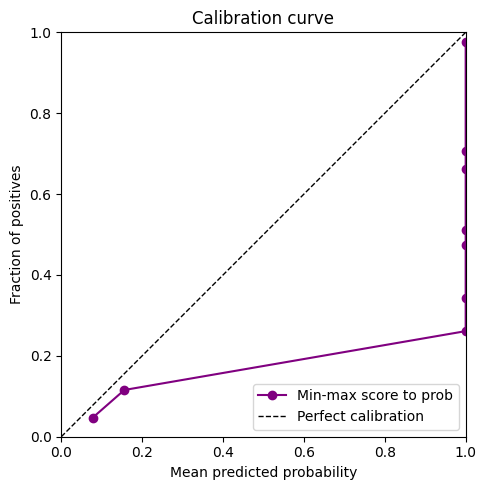

In [ ]:

from sklearn.calibration import calibration_curve

prob_mean, frac_pos = calibration_curve(label, prob, n_bins=10, strategy="uniform")

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(prob_mean, frac_pos, "o-", color="purple", label="Min-max score to prob")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration curve")
ax.legend(loc="lower right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

# Multivariate performance estimation

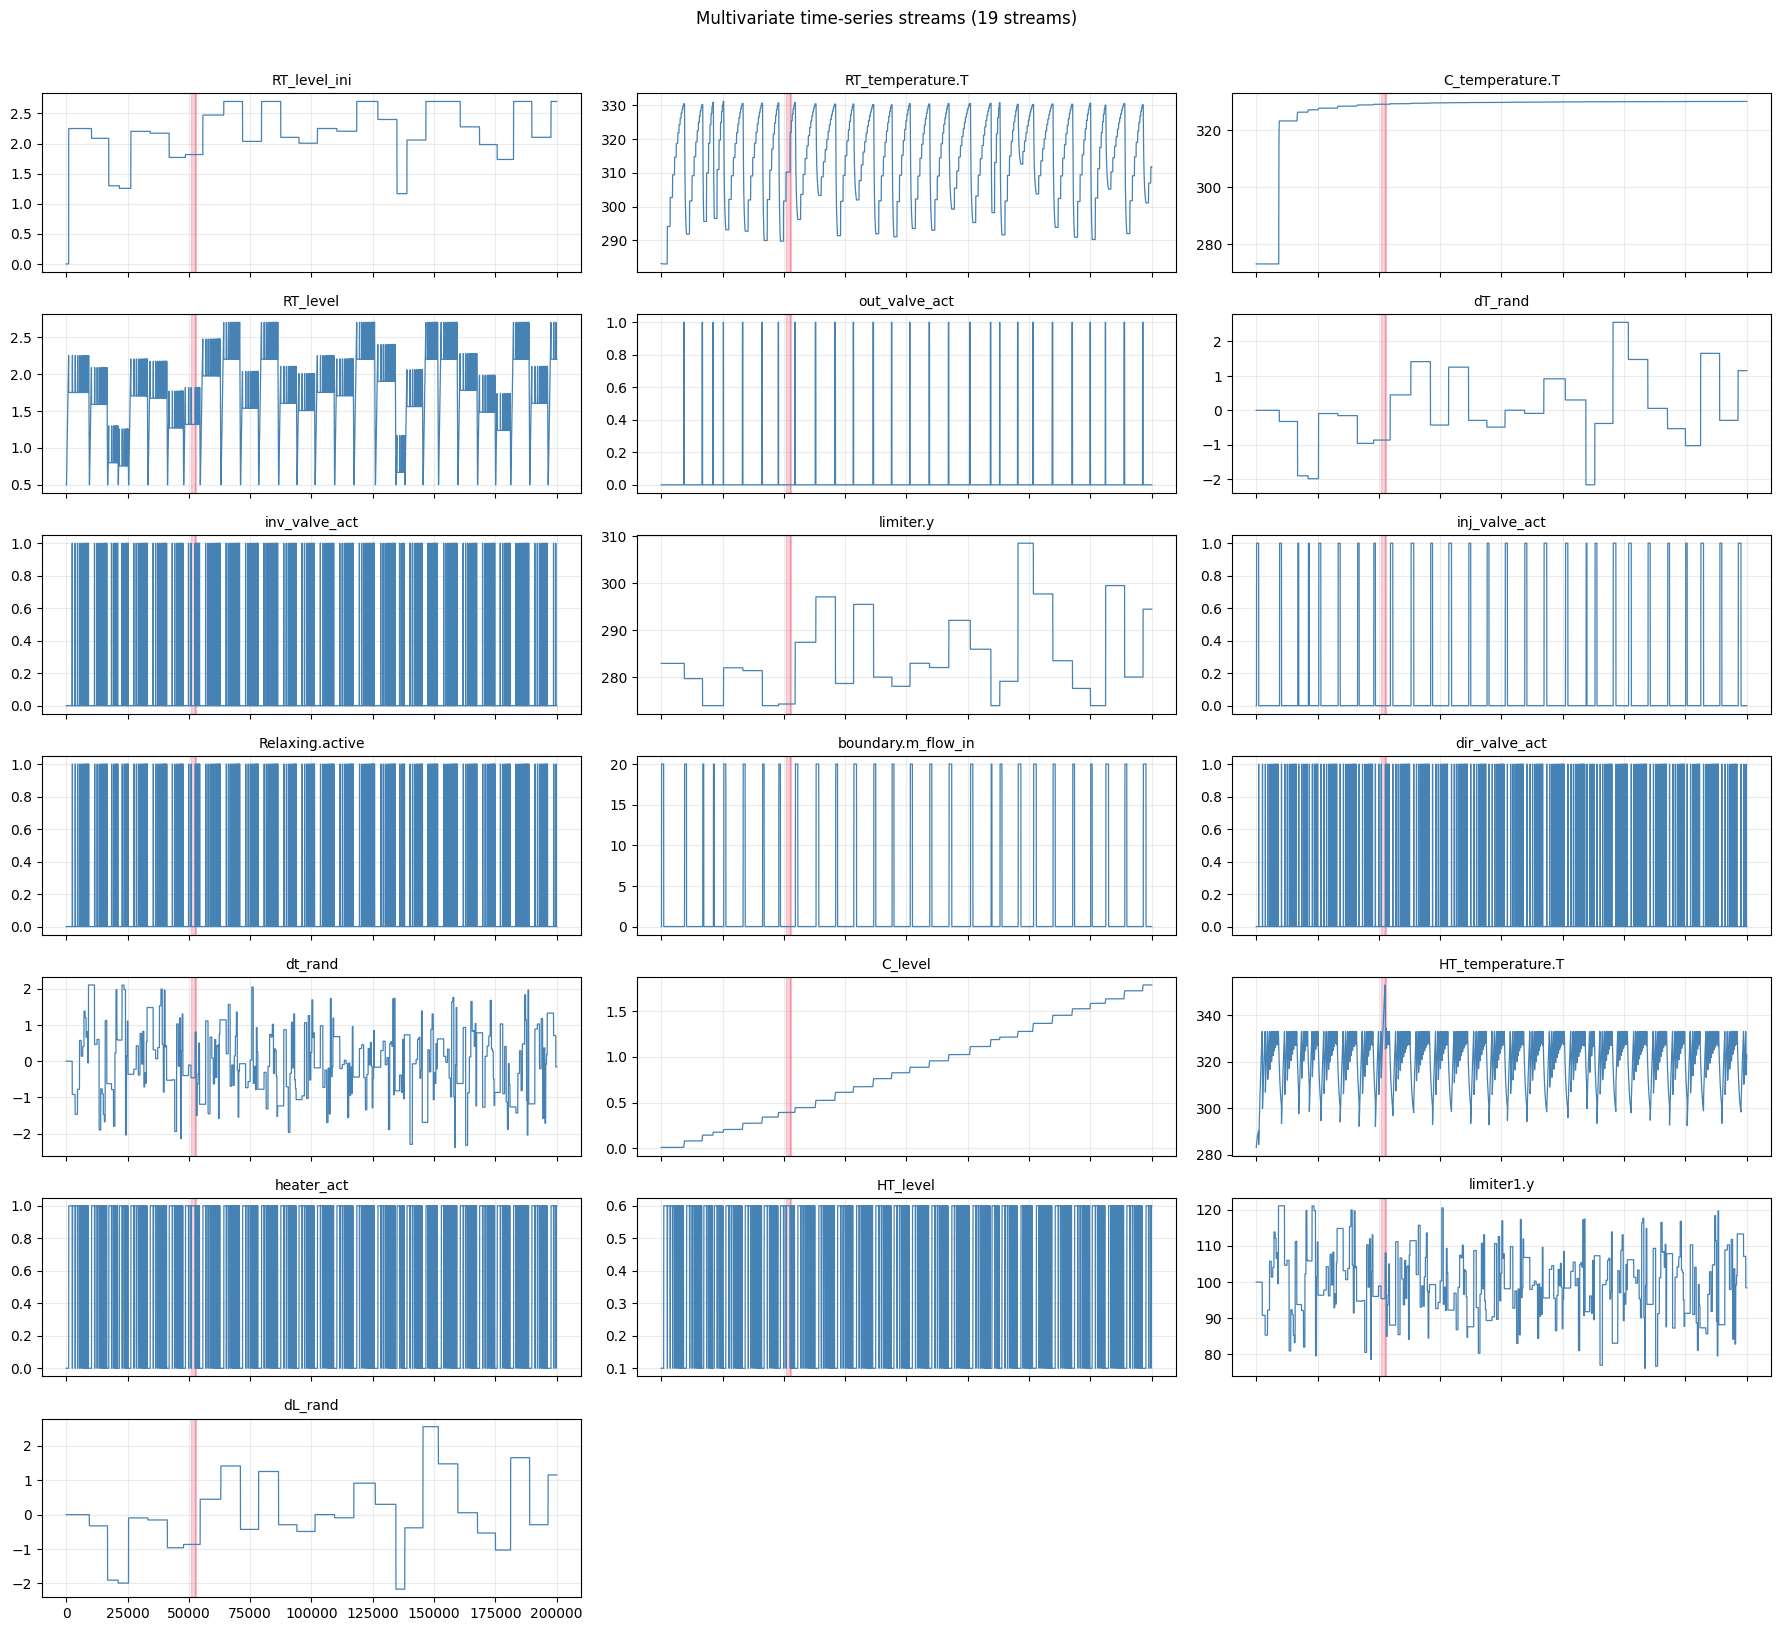

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression



path = r'C:\Users\Valentin\Desktop\tsfm-2026\Datasets\TSB-AD-M\033_GHL_id_2_Sensor_tr_50000_1st_51001.csv'
df = pd.read_csv(path)

if "Label" not in df.columns:
    raise ValueError("Target column `label` was not found in the dataset.")

# Keep numeric streams only, excluding label
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
stream_cols = [c for c in numeric_cols if c != "Label"]

if len(stream_cols) == 0:
    raise ValueError("No numeric stream columns found (excluding `label`).")

# Handle NaNs for MI and plotting
work_df = df[stream_cols + ["Label"]].copy()
work_df = work_df.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")

if work_df.empty:
    raise ValueError("No valid rows remain after dropping NaN/inf values.")

# 1) Plot all streams with dynamic subplots + anomaly overlay from Label (1 = anomaly)
n_streams = len(stream_cols)
ncols = 3 if n_streams > 6 else 2 if n_streams > 1 else 1
nrows = int(np.ceil(n_streams / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 2.3 * nrows), sharex=True)
axes = np.array(axes).reshape(-1)

label_arr = work_df["Label"].astype(int).values
anomaly_mask = label_arr == 1

# Build contiguous anomaly segments for shaded overlay
anomaly_segments = []
in_segment = False
start_idx = 0
for idx, is_anomaly in enumerate(anomaly_mask):
    if is_anomaly and not in_segment:
        in_segment = True
        start_idx = idx
    elif not is_anomaly and in_segment:
        in_segment = False
        anomaly_segments.append((start_idx, idx - 1))
if in_segment:
    anomaly_segments.append((start_idx, len(anomaly_mask) - 1))

for i, col in enumerate(stream_cols):
    ax = axes[i]
    ax.plot(work_df[col].values, linewidth=0.9, color="steelblue")

    # Highlight anomaly periods (Label == 1)
    for seg_start, seg_end in anomaly_segments:
        ax.axvspan(seg_start, seg_end, color="crimson", alpha=0.18)

    ax.set_title(col, fontsize=10)
    ax.grid(alpha=0.25)

# Add one shared legend entry for anomaly shading
# if anomaly_segments:
#     axes[0].axvspan(0, 0, color="crimson", alpha=0.18, label="Anomaly (Label=1)")
#     # axes[0].legend(loc="upper right", fontsize=8)

for j in range(n_streams, len(axes)):
    axes[j].axis("off")

fig.suptitle(f"Multivariate time-series streams ({n_streams} streams)", y=1.01)
plt.tight_layout()
plt.show()

# # 2) Pairwise mutual information matrix between streams
# X_streams = work_df[stream_cols].values
# mi_matrix = np.zeros((n_streams, n_streams), dtype=float)

# for i in range(n_streams):
#     xi = X_streams[:, i]
#     for j in range(i, n_streams):
#         if i == j:
#             # Entropy-like self-dependency surrogate from MI(x, x)
#             mi_val = mutual_info_regression(xi.reshape(-1, 1), xi, random_state=42)[0]
#         else:
#             xj = X_streams[:, j]
#             mi_ij = mutual_info_regression(xi.reshape(-1, 1), xj, random_state=42)[0]
#             mi_ji = mutual_info_regression(xj.reshape(-1, 1), xi, random_state=42)[0]
#             mi_val = 0.5 * (mi_ij + mi_ji)
#         mi_matrix[i, j] = mi_val
#         mi_matrix[j, i] = mi_val

# mi_df = pd.DataFrame(mi_matrix, index=stream_cols, columns=stream_cols)

# fig, ax = plt.subplots(figsize=(min(1.0 * n_streams + 3, 22), min(0.9 * n_streams + 3, 22)))
# im = ax.imshow(mi_matrix, cmap="viridis", aspect="auto")
# ax.set_xticks(np.arange(n_streams))
# ax.set_yticks(np.arange(n_streams))
# ax.set_xticklabels(stream_cols, rotation=90)
# ax.set_yticklabels(stream_cols)
# ax.set_title("Mutual information matrix between streams")
# plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="MI")
# plt.tight_layout()
# plt.show()

# 3) Mutual information of each stream relative to target label
# label = work_df["Label"]
# X = work_df[stream_cols]

# # Choose MI estimator based on label type
# is_discrete_label = (
#     pd.api.types.is_integer_dtype(label)
#     or pd.api.types.is_bool_dtype(label)
#     or label.nunique() <= 20
# )

# if is_discrete_label:
#     mi_to_label = mutual_info_classif(X, label.astype(int), random_state=42)
# else:
#     mi_to_label = mutual_info_regression(X, label, random_state=42)

# mi_label_df = pd.DataFrame({"stream": stream_cols, "mi_to_label": mi_to_label}).sort_values(
#     "mi_to_label", ascending=False
# )

# fig, ax = plt.subplots(figsize=(10, max(4, 0.25 * n_streams)))
# ax.barh(mi_label_df["stream"], mi_label_df["mi_to_label"], color="teal")
# ax.invert_yaxis()
# ax.set_xlabel("Mutual information with label")
# ax.set_ylabel("Stream")
# ax.set_title("Mutual information of each stream relative to target (label)")
# ax.grid(axis="x", alpha=0.3)
# plt.tight_layout()
# plt.show()

# print("\nMutual information (stream -> label), sorted descending:")
# print(mi_label_df.reset_index(drop=True).round(6))

In [ ]:
import pandas as pd
import os

file_path = r'.\Datasets\TSB-AD-M\032_GHL_id_1_Sensor_tr_50000_1st_65001.csv'
col_name = 'HT_temperature.T'  # Change to your column name

# Read file and save both the column and label
df = pd.read_csv(file_path)
df[[col_name, 'Label']].to_csv(f"multy_{os.path.basename(file_path)}", index=False)

print(f"Saved: multy_{os.path.basename(file_path)} with columns: {col_name} and Label")

Saved: multy_032_GHL_id_1_Sensor_tr_50000_1st_65001.csv with columns: HT_temperature.T and Label


In [ ]:
import pandas as pd
import os
import numpy as np
from TSB_AD.model_wrapper import *
from TSB_AD.HP_list import Optimal_Uni_algo_HP_dict, Optimal_Multi_algo_HP_dict
from TSB_AD.evaluation.metrics import get_metrics
from sklearn.preprocessing import MinMaxScaler
from TSB_AD.utils.slidingWindows import find_length_rank

model_name_m = 'PCA'

# Multivariate case - exclude label column
stream_cols = [c for c in df.columns if c != "Label"]
data_m = df[stream_cols].values.astype(float)  # Convert to numpy array

# Check if multivariate (more than 1 feature column)
if len(stream_cols) > 0:
    output_m = run_Unsupervise_AD(model_name_m, data_m, **Optimal_Multi_algo_HP_dict[model_name_m])
    
    # Handle multivariate for evaluation
    slidingWindow = find_length_rank(data_m, rank=1)
    
    if isinstance(output_m, np.ndarray):
        output_m = MinMaxScaler(feature_range=(0,1)).fit_transform(output_m.reshape(-1,1)).ravel()
        evaluation_result = get_metrics(output_m, label, slidingWindow=slidingWindow, pred=output_m > (np.mean(output_m)+3*np.std(output_m)))
        selected_metrics = {
            'AUC-ROC': evaluation_result.get('AUC-ROC'),
            'Standard-F1': evaluation_result.get('Standard-F1'),
            'ECE': evaluation_result.get('ECE')
        }
        print("Multivariate results:", selected_metrics)

An error occurred while running the model 'run_Sub_PCA': not enough values to unpack (expected 2, got 1)
Multivariate results: {'AUC-ROC': 0.4649003551345704, 'Standard-F1': 0.0, 'ECE': 0.26586608165747}


Sub_IForest HT_temp col:
python -m TSB_AD.main --AD_Name Sub_IForest --filename multy_032_GHL_id_1_Sensor_tr_50000_1st_65001.csv                     
{'AUC-ROC': 0.7707087715115432, 'Standard-F1': 0.3383275261324042, 'ECE': 0.14798696715585163}

Sub_PCA HT_temp call:
python -m TSB_AD.main --AD_Name Sub_PCA --filename multy_032_GHL_id_1_Sensor_tr_50000_1st_65001.csv
{'AUC-ROC': 0.7230349036300053, 'Standard-F1': 0.11661267931513189, 'ECE': 0.18465955260358385}
(tsb-ad) PS C:\Users\Valentin\Desktop\tsfm-2026> 
